# Họ và Tên
# MSSV:

## Câu 1 (2 điểm) Chọn một ảnh bất kỳ (tự đặt tên, ví dụ `pic1.jpg`) và thực hiện:

- Làm mờ ảnh bằng box filter. (0.5 điểm)  
- Áp dụng Laplacian để phát hiện biên. (0.5 điểm)  
- Chuyển đổi ảnh sang ảnh âm bản (negative). (0.5 điểm)  
- Chuyển sang không gian màu HSV và lưu 3 kênh H, S, V riêng biệt.  lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm) (0.5 điểm)


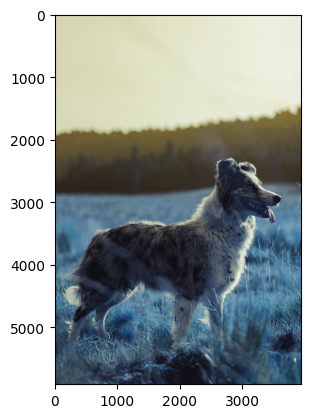

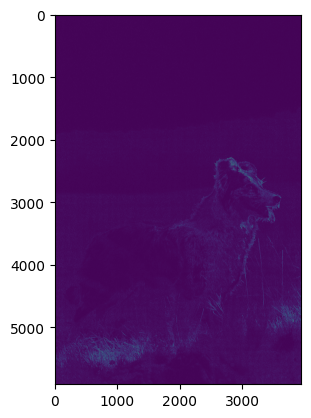

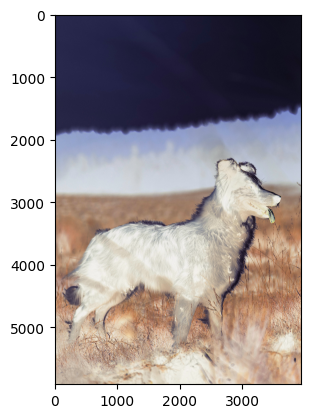

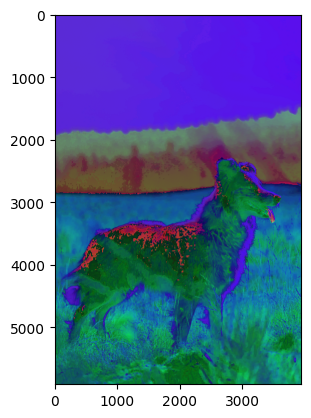

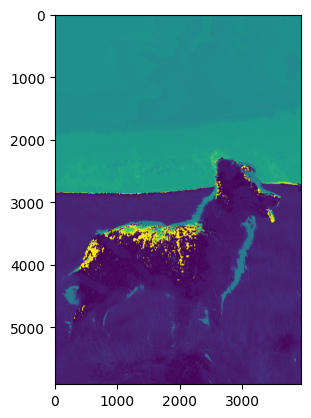

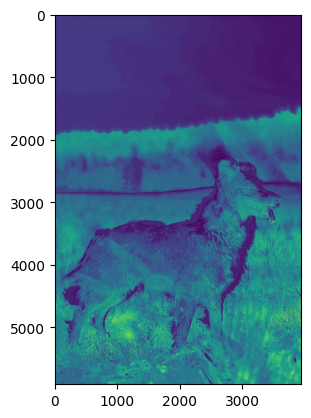

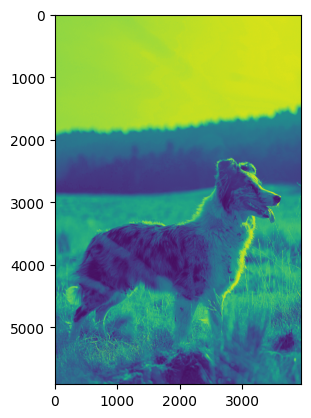

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh gốc
img = cv2.imread('pic1.jpg')

# 1. Làm mờ bằng Box Filter
blur = cv2.blur(img, (5, 5))
plt.imshow(blur)
plt.show()


# 2. Phát hiện biên bằng Laplacian
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
plt.imshow(laplacian)
plt.show()

# 3. Chuyển sang ảnh âm bản
negative = 255 - img
plt.imshow(negative)
plt.show()

# 4. Chuyển sang HSV và tách H, S, V
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.imshow(hsv)
plt.show()
H, S, V = cv2.split(hsv)
cv2.imwrite('pic1_L.jpg', H)  
plt.imshow(H)
plt.show()
cv2.imwrite('pic1_A.jpg', S)
plt.imshow(S)
plt.show()
cv2.imwrite('pic1_B.jpg', V)
plt.imshow(V)
plt.show()



### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật chuyển đổi không gian màu và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Chuyển sang ảnh xám (Grayscale) (0.5 điểm)  
* Chuyển sang HSV (0.5 điểm)  
* Chuyển sang LAB (0.5 điểm)  
* Cân bằng histogram (0.5 điểm)  
* Adaptive Thresholding (tham số ngẫu nhiên) (0.5 điểm)  
* CLAHE (Contrast Limited Adaptive Histogram Equalization) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* G: Grayscale  
* H: HSV  
* L: LAB  
* Q: Histogram Equalization  
* A: Adaptive Threshold  
* C: CLAHE (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_gray_flower.jpg`, `result_clahe_img1.jpg` (0.5 điểm)


In [23]:
import cv2
import os

images = ['pic1.jpg', 'pic1_A.jpg', 'pic1_B.jpg']  

def process_image(img, method, name):
    if method == 'G':
        result = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        outname = f'result_gray_{name}'
    elif method == 'H':
        result = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        outname = f'result_hsv_{name}'
    elif method == 'L':
        result = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        outname = f'result_lab_{name}'
    elif method == 'Q':
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result = cv2.equalizeHist(gray)
        outname = f'result_hist_{name}'
    elif method == 'A':
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 11, 2)
        outname = f'result_thresh_{name}'
    elif method == 'C':
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        result = cv2.merge((cl, a, b))
        result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)
        outname = f'result_clahe_{name}'
    else:
        print("Phím không hợp lệ.")
        return None

    cv2.imwrite(outname, result)
    print(f"Đã lưu: {outname}")

# Menu
print("Chọn phím xử lý ảnh:")
print("G: Grayscale | H: HSV | L: LAB | Q: Histogram | A: Adaptive Threshold | C: CLAHE")
key = input("Nhập phím: ").upper()

# Xử lý từng ảnh
for filename in images:
    if not os.path.exists(filename):
        print(f"Không tìm thấy ảnh: {filename}")
        continue
    img = cv2.imread(filename)
    process_image(img, key, filename)


Chọn phím xử lý ảnh:
G: Grayscale | H: HSV | L: LAB | Q: Histogram | A: Adaptive Threshold | C: CLAHE
Đã lưu: result_lab_pic1.jpg
Đã lưu: result_lab_pic1_A.jpg
Đã lưu: result_lab_pic1_B.jpg


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Cắt ảnh đầu tiên theo tỉ lệ 80% ở giữa. (0.5 điểm)  
* Xoay ảnh thứ hai 90 độ và lật dọc. (0.5 điểm)  
* Thu nhỏ ảnh thứ ba xuống 1/3 kích thước ban đầu và áp dụng Median Blur với kernel 7x7. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba theo công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.7, 1.8], \quad \beta \in [-40, 40]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


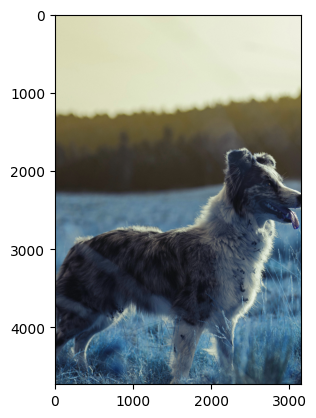

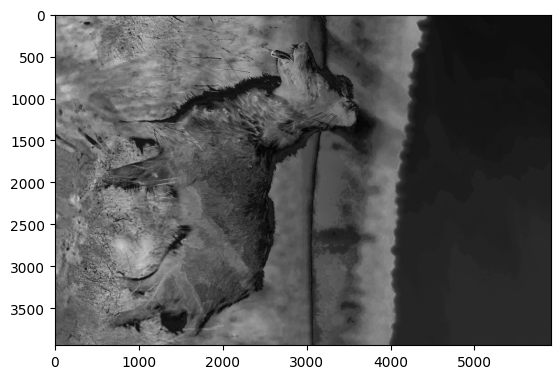

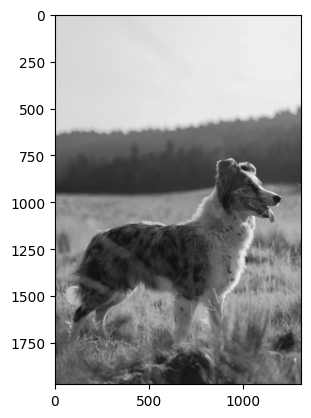

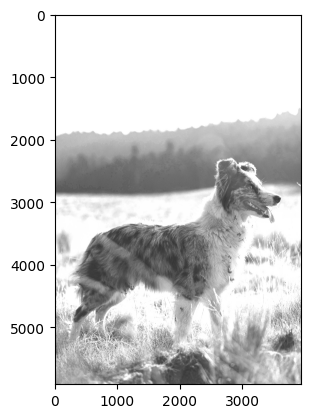

In [ ]:
import cv2
import numpy as np

images = ['pic1.jpg', 'pic1_A.jpg', 'pic1_B.jpg']

# 1. Cắt ảnh đầu tiên (giữ 80% ở giữa)
img1 = cv2.imread(images[0])
h, w = img1.shape[:2]
x1, y1 = int(w*0.1), int(h*0.1)
x2, y2 = int(w*0.9), int(h*0.9)
cropped = img1[y1:y2, x1:x2]
plt.imshow(cropped)
plt.show()
# 2. Xoay 90 độ và lật dọc ảnh thứ hai
img2 = cv2.imread(images[1])
rotated = cv2.rotate(img2, cv2.ROTATE_90_CLOCKWISE)
flipped = cv2.flip(rotated, 0)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.show()


# 3. Thu nhỏ ảnh thứ ba + làm mờ Median
img3 = cv2.imread(images[2])
h3, w3 = img3.shape[:2]
resized = cv2.resize(img3, (w3//3, h3//3))
blurred = cv2.medianBlur(resized, 7)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.show()

# 4. Thay đổi độ sáng và tương phản
alpha = 1.5  
beta = 30    
adjusted = cv2.convertScaleAbs(img3, alpha=alpha, beta=beta)
plt.imshow(adjusted)
plt.show()


# Chúc các bạn làm bài may mắn, hi vọng mọi người qua môn tất cả được 10.